In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve 
from sklearn.ensemble import RandomForestClassifier 



In [2]:
df = pd.read_csv('train.csv')
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived', 'Parch', 'SibSp']]
df.dropna(inplace=True)

#convert sex to numbers 0-1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(df.shape)
print(df.isnull().sum())
df.head(10)



(714, 7)
Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
Parch       0
SibSp       0
dtype: int64


,Pclass,Sex,Age,Fare,Survived,Parch,SibSp
0,3,0,22.0,7.2500,0,0,1
1,1,1,38.0,71.2833,1,0,1
2,3,1,26.0,7.9250,1,0,0
3,1,1,35.0,53.1000,1,0,1
4,3,0,35.0,8.0500,0,0,0
6,1,0,54.0,51.8625,0,0,0
7,3,0,2.0,21.0750,0,1,3
8,3,1,27.0,11.1333,1,2,0
9,2,1,14.0,30.0708,1,0,1
10,3,1,4.0,16.7000,1,1,1


In [3]:
#train/test split  

x =df.drop(columns='Survived')
y = df['Survived']

#train split test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
#train the model (logistic regression)

model = LogisticRegression()
model.fit(x_train, y_train)

print("Model Trained Successfully")

#prediction 
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

#ROC and AUC 

y_proba = model.predict_proba(x_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")


fpr, tpr, thresholds = roc_curve(y_test, y_proba)

#Decision Tree

dec_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
dec_tree.fit(x_train, y_train)

dec_proba = dec_tree.predict_proba(x_test)[:, 1]
fpr_tree , tpr_tree, thresholds_tree = roc_curve(y_test, dec_proba)

tree_test_AUC = roc_auc_score(y_test, dec_proba)
tree_train_AUC = roc_auc_score(y_train, dec_tree.predict_proba(x_train)[:, 1])
print(f"Decision Tree | train AUC: {tree_train_AUC:.4f} | test AUC: {tree_test_AUC:.4f}")

# Random Forest 

model_rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
model_rf.fit(x_train, y_train)

print("Model Trained Successfully")

rf_proba = model_rf.predict_proba(x_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_proba)

train_auc = roc_auc_score(y_train, model_rf.predict_proba(x_train)[:, 1])
test_auc = roc_auc_score(y_test, rf_proba)
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

importances = model_rf.feature_importances_
feature_names = x.columns
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")






Model Trained Successfully
Accuracy: 0.7483
ROC-AUC: 0.8164
Decision Tree | train AUC: 0.8766 | test AUC: 0.7924
Model Trained Successfully
Train AUC: 0.9995
Test AUC: 0.8056
Pclass: 0.0816
Sex: 0.2752
Age: 0.2882
Fare: 0.2762
Parch: 0.0364
SibSp: 0.0424


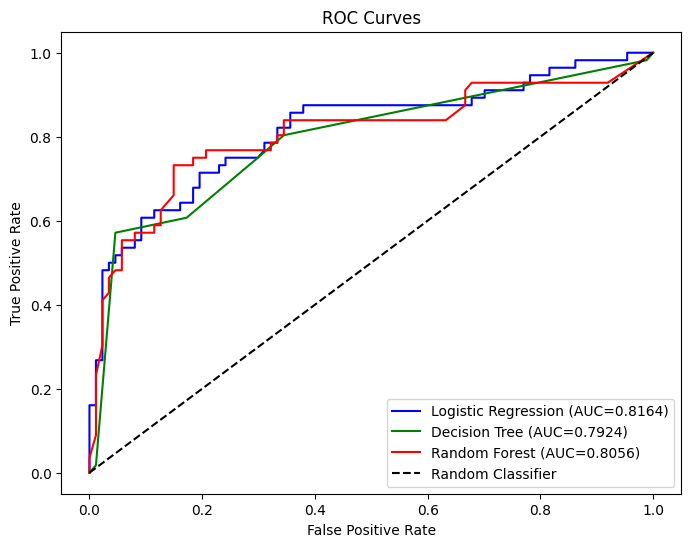

In [11]:
# plot three different ROC curves on the same graph 

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label= f"Logistic Regression (AUC={roc_auc:.4f})", color="blue")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC={tree_test_AUC:.4f})", color="green")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={test_auc:.4f})", color="red")
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

Takeway: Overall, Logistic Regression model has better true positive rates for given false positive rates (Random Forest seems to be doing well with low false positive rates but oberall doesn't beat Logistic Regression)